In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
# Adjust the seed for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

In [4]:
# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANELS = 3
EMBED_DIM = 256
NUM_HEADS = 16
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

In [5]:
# Image transformations
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

In [6]:
# Getting the training dataset
train_dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]


In [7]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.2, 0.2))
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [8]:
# Getting the testing dataset
test_dataset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

In [9]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.2, 0.2))
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [10]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoader: {train_loader}, {test_loader}")
print(f"Length of train_loader: {len(train_loader)}")
print(f"Length of test_loader: {len(test_loader)}")

DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x7b208ed08590>, <torch.utils.data.dataloader.DataLoader object at 0x7b208ed07170>
Length of train_loader: 391
Length of test_loader: 79


In [11]:
# Patch embedding class
class PatchEmbedding(nn.Module):
  def __init__(self, img_size, patch_size, in_chanels, embed_dim):
    super().__init__()
    self.patch_size = patch_size
    self.proj =  nn.Conv2d(in_channels=in_chanels, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size)
    num_patches = (img_size // patch_size) ** 2

    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
    self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

  def forward(self, x: torch.Tensor):
    B = x.size(0)
    x = self.proj(x)
    x = x.flatten(2).transpose(1, 2)
    cls_token = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_token, x), dim=1)
    x = x + self.pos_embedding
    return x

In [12]:
# MLP class
class MLP(nn.Module):
  def __init__(self, in_features, hidden_features, drop_rate):
    super().__init__()
    self.fc1 = nn.Linear(in_features=in_features, out_features=hidden_features)
    self.fc2 = nn.Linear(in_features=hidden_features, out_features=in_features)
    self.dropout = nn.Dropout(drop_rate)

  def forward(self, x):
    x = self.dropout(F.gelu(self.fc1(x)))
    x = self.dropout(self.fc2(x))
    return x

In [13]:
# Encoder class
class TransformerEncoder(nn.Module):
  def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
    super().__init__()
    self.norm1 = nn.LayerNorm(embed_dim)
    self.attn = nn.MultiheadAttention(embed_dim, num_heads, drop_rate, batch_first=True)
    self.norm2 = nn.LayerNorm(embed_dim)
    self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

  def forward(self, x):
    x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
    x = x + self.mlp(self.norm2(x))
    return x

In [14]:
# VisionTransformer class
class VisionTransformer(nn.Module):
  def __init__(self, img_size, patch_size, in_chanels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate):
    super().__init__()
    self.patch_embedding = PatchEmbedding(img_size, patch_size, in_chanels, embed_dim)
    self.encoder = nn.Sequential(*[
        TransformerEncoder(embed_dim, num_heads, mlp_dim, drop_rate)
        for _ in range(depth)
    ])
    self.norm = nn.LayerNorm(embed_dim)
    self.head = nn.Linear(embed_dim, num_classes)

  def forward(self, x):
    x = self.patch_embedding(x)
    x = self.encoder(x)
    x = self.norm(x)
    cls_token = x[:, 0]
    return self.head(cls_token)

In [15]:
# Initialize the model
model = VisionTransformer(
    IMAGE_SIZE,
    PATCH_SIZE,
    CHANELS,
    NUM_CLASSES,
    EMBED_DIM,
    DEPTH,
    NUM_HEADS,
    MLP_DIM,
    DROP_RATE
).to(device)

In [16]:
model

VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): TransformerEncoder(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoder(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
    

In [17]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [18]:
# Training function
def train(model, train_loader, criterion, optimizer):
  model.train()

  total_loss, correct = 0, 0
  for x, y in train_loader:
    x, y = x.to(device), y.to(device) # move data into device (gpu)
    optimizer.zero_grad()

    # forward pass
    output = model(x)

    #calculate loss
    loss  = criterion(output, y)

    # backpropagation
    loss.backward()

    # update weights
    optimizer.step()

    total_loss += loss.item() * x.size(0)
    correct += torch.sum(torch.argmax(output, dim=1) == y).item()

  return total_loss / len(train_loader.dataset), correct / len(train_loader.dataset)

In [19]:
# Evaluation function
def evaluate(model, test_loader):
  model.eval()

  correct = 0
  with torch.inference_mode():
    for x, y in test_loader:
      x, y = x.to(device), y.to(device)
      output = model(x)
      correct += torch.sum(torch.argmax(output, dim=1) == y).item()

  return correct / len(test_loader.dataset)

In [20]:
import time
from tqdm.auto import tqdm

# Training
train_losses, train_accuracies = [], []
test_accuracies = []

epoch_bar = tqdm(range(EPOCHS), desc="Training")

for epoch in epoch_bar:
    start_time = time.time()

    train_loss, train_accuracy = train(model, train_loader, criterion, optimizer)
    test_accuracy = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    epoch_time = time.time() - start_time

    epoch_bar.set_postfix({
        "loss": f"{train_loss:.4f}",
        "train_acc": f"{train_accuracy:.2f}%",
        "test_acc": f"{test_accuracy:.2f}%",
        "time": f"{epoch_time:.1f}s"
    })

Training:   0%|          | 0/50 [00:00<?, ?it/s]

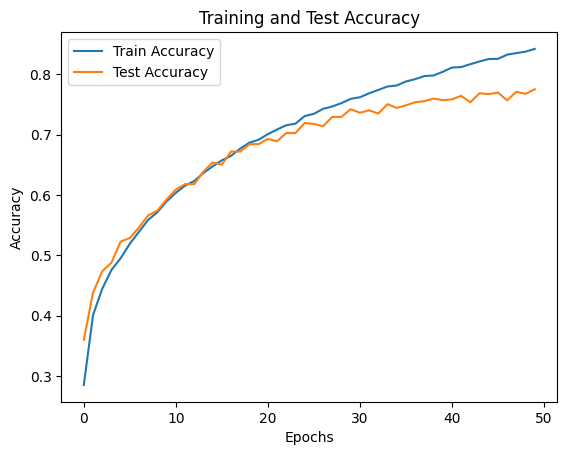

In [21]:
# Accuracy plot
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Test Accuracy")
plt.show()

In [22]:
# Showing some samples
def show_samples(model, dataset, classes, grid_size=3):
  model.eval()

  fig, axes = plt.subplots(grid_size, grid_size, figsize=(9, 9))
  for i in range(grid_size):
    for j in range(grid_size):
      idx = random.randint(0,len(dataset) - 1)
      img, true_label = dataset[idx]
      input_tensor = img.unsqueeze(dim=0).to(device)
      with torch.inference_mode():
        output = model(input_tensor)
        _, predicted = torch.max(output.data, 1)

      img = img / 2 + 0.5
      npimg = img.cpu().numpy()
      axes[i, j].imshow(np.transpose(npimg, (1, 2, 0)))
      truth = classes[true_label] == classes[predicted.item()]
      if truth:
        color = "g"
      else:
        color = "r"

      axes[i, j].set_title(f"Truth: {classes[true_label]}\n, Predicted: {classes[predicted.item()]}", fontsize=10, c=color)
      axes[i, j].axis("off")
  plt.tight_layout()
  plt.show()

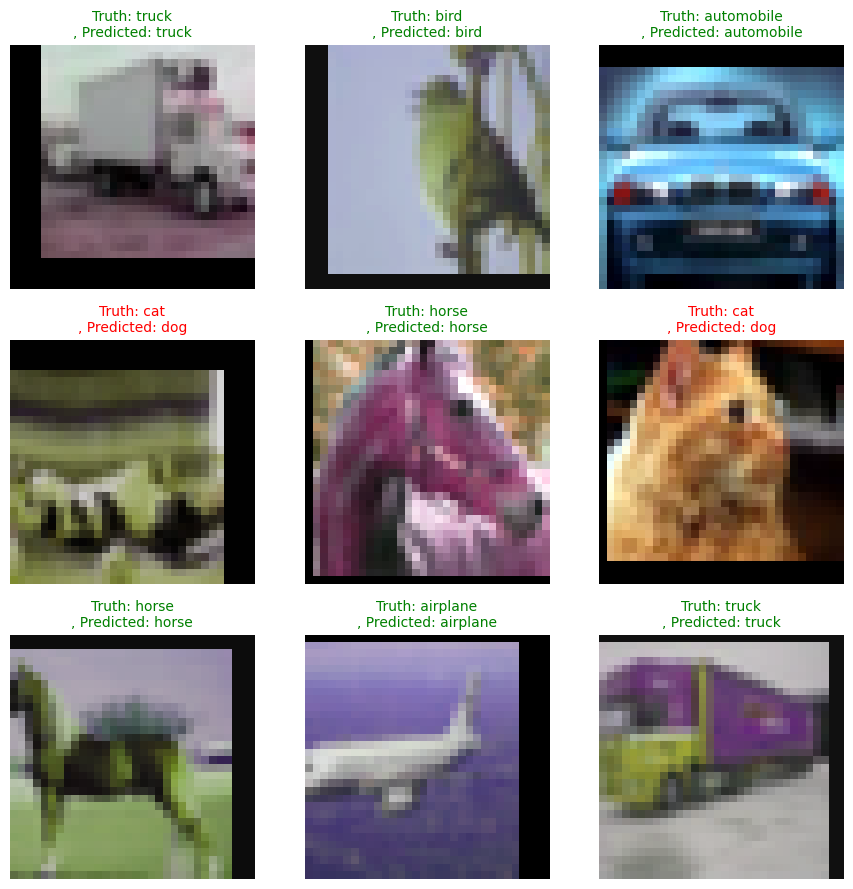

In [23]:
show_samples(model, test_dataset, train_dataset.classes, 3)